# 🪐 PROJE 1 — Uzay: Yeni Bir Dünya Buldun mu?
## Mini Proje — Araştırma Projeniz
*Bugün (Gün 2) seçtiğiniz proje — kampın son günü "Bilimsel Yöntem" oturumunda sunulacak*

**Veri seti:** ~7300 GERÇEK NASA Kepler ötegezegen adayı
**Kaynak:** NASA Exoplanet Archive — gerçek 2009-2018 Kepler uydusu gözlemleri

Astronomlar yıldız parlaklığındaki kısa düşüşlere bakar (transit). Bazıları gerçek gezegen, bazıları ikili yıldız sistemi veya gürültü.

### 🎯 Sizin göreviniz: Hangileri **gerçek**, hangileri **yanlış pozitif**?

**Aşağıdaki seçeneklerden en az 3'ünü deneyin:**
1. **Sınıflandırma modeli** eğitin (gerçek vs yanlış pozitif)
2. 🌟 **Yıldız tipi analizi:** M cüce vs G yıldızı — gezegenler farklı mı?
3. 🔥 **Sıcak Jüpiter avı:** Çok kısa yörünge + büyük gezegen — kaç tane?
4. 🌍 **Yaşanabilir bölge** Goldilocks gezegenleri
5. 🔭 **Çok-gezegenli sistemler:** Tek yıldızın kaç gezegeni var?
6. 🌎 **Dünya benzeri** filtreleyin (0.8-1.5 yarıçap, 250-350 K)
7. 😨 Modelin **en güvensiz** olduğu adaylar — astronomlara "şuna tekrar bakın" listesi

---

🌌 **İlham:** NASA Kepler 2009-2018 arası 5000+ gerçek ötegezegen keşfetti. Sizin modeliniz aynı işin bir prototipi!

> 🤖 **Bu, defterin "çıktılı önizleme" sürümüdür.** Asıl çalışacağınız Colab defteri
> [`notebooks/`](../notebooks) klasöründe. Buraya, normal hücrelerin **arasına**:
> 📂 *veri açıklamaları*, 📊 *her grafiğin/istatistiğin ne anlattığı*, 🔧 *deneyebileceğiniz
> varyasyonlar* (çalıştırılmış hâlde) ve mini projelerde 🎤 *sunum rehberleri* eklendi.
> Bu eklemeler **alıntı kutularıyla** ayrılmıştır; siz de aynı şeyleri kendi defterinizde deneyebilirsiniz.


In [2]:
import os
from python_code.helper_tr import *
import pandas as pd
import numpy as np

uzay = veri_yukle('input_data/uzay_otegezegen.csv')
print(f'\nGerçek gezegen oranı: %{uzay["gercek_gezegen"].mean()*100:.1f}')
print(f'Yaşanabilir bölge oranı: %{uzay["yasanabilir_bolge"].mean()*100:.1f}')


📂 'input_data/uzay_otegezegen.csv' okunuyor...
✅ Yüklendi: 7327 satır × 12 sütun

İlk 5 satır:
     aday_id  yorunge_periyodu_gun  transit_suresi_saat  \
0  K00752.01              9.488036              2.95750   
1  K00752.02             54.418383              4.50700   
2  K00754.01              1.736952              2.40641   
3  K00755.01              2.525592              1.65450   
4  K00756.01             11.094321              4.59450   

   transit_derinligi_ppm  gezegen_yaricap_dunya  yildiz_sicakligi_K  \
0                  615.8                   2.26              5455.0   
1                  874.8                   2.83              5455.0   
2                 8079.2                  33.46              5805.0   
3                  603.3                   2.75              6031.0   
4                 1517.5                   3.90              6046.0   

   yildiz_yaricap_gunes  denge_sicakligi_K  sinyal_gurultu_orani  \
0                 0.927              793.0             

## 📂 Veriyi Tanıyalım — Kepler Ötegezegen Adayları

Bu veri, NASA'nın **Kepler Uzay Teleskobu** gözlemlerinden türetilmiştir. Kepler, bir gezegen yıldızının önünden geçtiğinde yıldız ışığında oluşan minik **kararmayı (transit)** ölçer. Her satır böyle bir **aday sinyaldir** — ama her sinyal gerçek gezegen değildir!

- **Satır sayısı:** 7.327 aday sinyal
- **Gerçek gezegen oranı:** ~%37,5 (gerisi *yanlış pozitif*: yıldız lekesi, çift yıldız, gürültü…)
- **Yaşanabilir bölgede:** yalnızca ~%4

| Sütun | Anlamı |
|---|---|
| `yorunge_periyodu_gun` | Yıldız çevresinde 1 tur kaç gün (Dünya = 365) |
| `transit_suresi_saat` | Geçişin kaç saat sürdüğü |
| `transit_derinligi_ppm` | Yıldız ne kadar karardı — büyük = büyük gezegen |
| `gezegen_yaricap_dunya` | Gezegenin yarıçapı (Dünya = 1) |
| `yildiz_sicakligi_K` | Yıldız sıcaklığı (Kelvin; Güneş ≈ 5778) |
| `denge_sicakligi_K` | Gezegenin tahmini sıcaklığı (Kelvin) |
| `sinyal_gurultu_orani` | Sinyalin netliği — yüksek = güvenilir |
| `yasanabilir_bolge` | Sıvı su olabilecek mesafede mi? (Doğru/Yanlış) |
| `gercek_gezegen` | **HEDEF:** doğrulanmış gerçek gezegen mi? |

💬 **Akranlarına anlat:** *“Teleskop binlerce ‘belki gezegen’ sinyali yakaladı; biz bunların hangisinin gerçek olduğunu ayırt etmeye ve içlerinden Dünya benzerlerini bulmaya çalışıyoruz.”*

---
### 👥 Grup Tartışması — Başlamadan Önce
*Grupça 2–3 dakika konuşun; tahminlerinizi sonra veriyle karşılaştıracaksınız.*
- Bir teleskop, bir yıldızın önünden geçen bir gölge gördü. Bunun **gerçek bir gezegen** mi yoksa **yanlış alarm** mı olduğunu anlamak için hangi ipuçlarına bakardınız? En az 3 fikir üretin.
- Sizce evrende kaç gezegen olabilir? Neye dayanarak tahmin ediyorsunuz?

## Adım 1: Veriyi Tanı

Sütunlar:
- `aday_id`: Gerçek KOI numarası (K00752 = Kepler-227 sistemi gibi)
- `yorunge_periyodu_gun`, `transit_suresi_saat`, `transit_derinligi_ppm`
- `gezegen_yaricap_dunya`, `denge_sicakligi_K`
- `yildiz_sicakligi_K`, `yildiz_yaricap_gunes`
- `sinyal_gurultu_orani`

In [3]:
veriyi_ozetle(uzay)

📊 Veri boyutu: 7327 satır × 12 sütun

Sütun tipleri:
aday_id                   object
yorunge_periyodu_gun     float64
transit_suresi_saat      float64
transit_derinligi_ppm    float64
gezegen_yaricap_dunya    float64
yildiz_sicakligi_K       float64
yildiz_yaricap_gunes     float64
denge_sicakligi_K        float64
sinyal_gurultu_orani     float64
yasanabilir_bolge           bool
gercek_gezegen              bool
durum                     object
dtype: object

Eksik değer sayısı (sütun başına):
aday_id                  0
yorunge_periyodu_gun     0
transit_suresi_saat      0
transit_derinligi_ppm    0
gezegen_yaricap_dunya    0
yildiz_sicakligi_K       0
yildiz_yaricap_gunes     0
denge_sicakligi_K        0
sinyal_gurultu_orani     0
yasanabilir_bolge        0
gercek_gezegen           0
durum                    0
dtype: int64

Sayısal sütunların özeti:
       yorunge_periyodu_gun  transit_suresi_saat  transit_derinligi_ppm  \
count           7327.000000          7327.000000           7.3

📊 **`veriyi_ozetle` çıktısı ne diyor?** Satır/sütun sayısını, eksik değerleri ve her sayısal sütunun min–ortalama–max değerlerini verir. Burada bazı sütunların **çok geniş aralıklı** olduğuna dikkat: yarıçap 0,1'den 200.000'e gidiyor — yani veride hem küçük kayalık adaylar hem de dev (muhtemelen hatalı) ölçümler var. Modeli kurmadan önce bu **uç değerleri** bilmek önemlidir.

## 🌟 Adım 2: Yıldız Tipi Analizi (M cüce vs G yıldız)

Yıldızlar sıcaklıklarına göre sınıflandırılır:
- **M cüce** (<3700 K): Soğuk, küçük, kırmızı. Yaşanabilir bölge yıldıza yakın
- **K** (3700-5200 K): Turuncu cüce
- **G** (5200-6000 K): Güneş gibi sarı
- **F** (6000-7500 K): Beyaz-sarı
- **A** (>7500 K): Beyaz, sıcak, kısa ömürlü

In [4]:
def yildiz_tipi(t):
    if t < 3700: return 'M (kırmızı cüce)'
    if t < 5200: return 'K (turuncu)'
    if t < 6000: return 'G (güneş gibi)'
    if t < 7500: return 'F (beyaz-sarı)'
    return 'A (beyaz)'
uzay['yildiz_tipi'] = uzay['yildiz_sicakligi_K'].apply(yildiz_tipi)

# Yıldız tipine göre gerçek gezegen oranı
tip_analiz = uzay.groupby('yildiz_tipi').agg(
    aday_sayisi=('gercek_gezegen', 'size'),
    gercek_oran=('gercek_gezegen', 'mean'),
    ort_yaricap=('gezegen_yaricap_dunya', 'mean'),
    ort_periyot=('yorunge_periyodu_gun', 'mean'),
).round(2)
print('Yıldız tipine göre:')
print(tip_analiz)

Yıldız tipine göre:
                  aday_sayisi  gercek_oran  ort_yaricap  ort_periyot
yildiz_tipi                                                         
A (beyaz)                 163         0.01       240.99        52.34
F (beyaz-sarı)           2309         0.25        32.37        56.77
G (güneş gibi)           3343         0.43        41.93        46.97
K (turuncu)              1420         0.48       347.60        46.01
M (kırmızı cüce)           92         0.53       166.98        32.18


📊 **Yıldız tipi tablosu ne anlatıyor?** Her yıldız tipinde kaç aday var, bunların ne oranı gerçek gezegen, ortalama yarıçap ve periyot ne. Yıldızlar sıcaklıklarına göre sınıflanır (M=kırmızı cüce → A=sıcak beyaz). Kepler bilinçli olarak çoğunlukla **Güneş benzeri (G/K)** yıldızlara baktı; bu yüzden onlar baskındır — yani veri *Kepler'in seçimini* yansıtır, evrenin tamamını değil. (Buna **örnekleme yanlılığı** denir.)

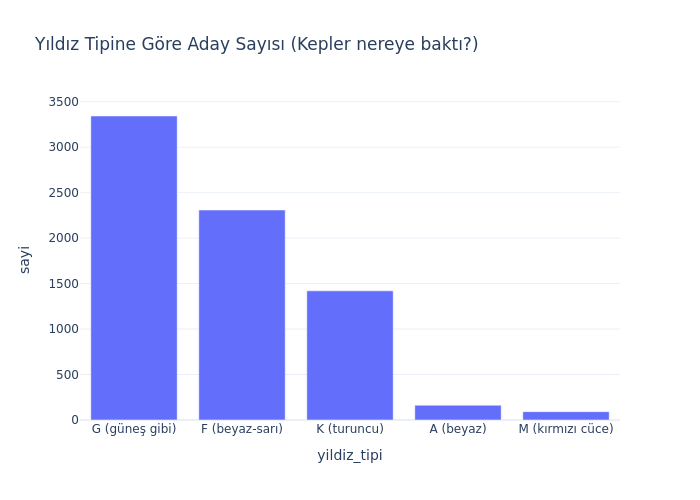

In [5]:
cubuk_grafigi(uzay, kategori_sutunu='yildiz_tipi',
              baslik='Yıldız Tipine Göre Aday Sayısı (Kepler nereye baktı?)')

🔧 **Sayı yerine ORAN sor.** `deger_sutunu='gercek_gezegen'` her tipte adayların ne kadarının **gerçek çıktığını** çizer:

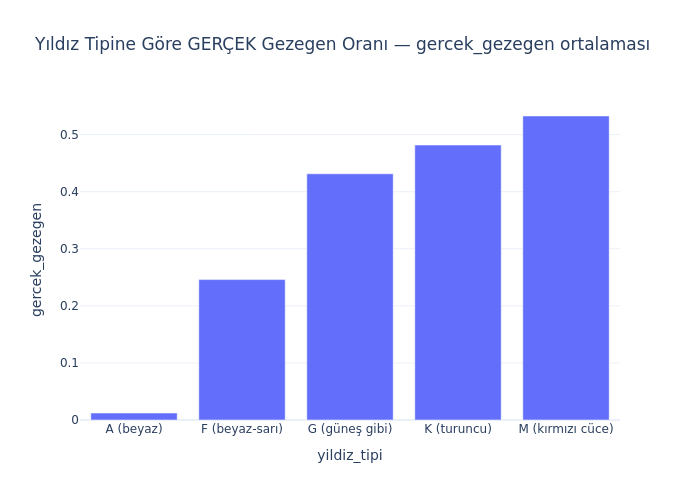

In [6]:
cubuk_grafigi(uzay, kategori_sutunu='yildiz_tipi', deger_sutunu='gercek_gezegen',
              baslik='Yıldız Tipine Göre GERÇEK Gezegen Oranı')

📊 **Nasıl yorumlanır?** Çok aday ≠ çok gerçek gezegen. Az aday olup yüksek oranda gerçek çıkan bir tip olabilir. Sunumda **‘nereye baktık’** (sayı) ile **‘ne bulduk’** (oran) farkını ayır.

**Görev:** Kepler hangi yıldız tipine en çok baktı? G ve K niye baskın? (İpucu: Kepler bilinçli olarak Güneş benzeri yıldızlara odaklandı)

---
### 👥 Grup Tartışması
- Kepler çoğunlukla belli tip yıldızlara baktı. Veride onların çok olması **'evrende en çok onlar var'** mı demek, yoksa **'biz en çok onlara baktık'** mı? Bu fark neden önemli?
- Buna bilimde **seçim yanlılığı** (selection bias) denir. Günlük hayattan benzer bir örnek bulabilir misiniz?

## 🔥 Adım 3: Sıcak Jüpiter Avı

**Sıcak Jüpiter** = Yörüngesi <10 gün + yarıçapı >8 Dünya = yıldızına çok yakın dev gezegen.
Bu gezegenler astronomları uzun yıllar şaşırttı (Jüpiter'imiz 12 yıllık yörüngede!).

🔥 Sıcak Jüpiter sayısı: 63
   Ortalama denge sıcaklığı: 1347 K
   En sıcak: 3559 K (kurşun erir!)
📈 Dağılım grafiği çiziliyor: yorunge_periyodu_gun - gezegen_yaricap_dunya


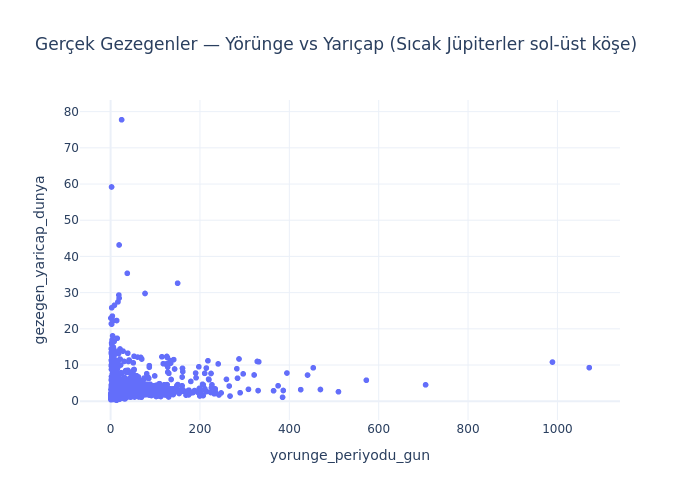

In [7]:
sicak_jupiter = uzay[
    (uzay['yorunge_periyodu_gun'] < 10) &
    (uzay['gezegen_yaricap_dunya'] > 8) &
    uzay['gercek_gezegen']
]
print(f'🔥 Sıcak Jüpiter sayısı: {len(sicak_jupiter)}')
print(f'   Ortalama denge sıcaklığı: {sicak_jupiter["denge_sicakligi_K"].mean():.0f} K')
print(f'   En sıcak: {sicak_jupiter["denge_sicakligi_K"].max():.0f} K (kurşun erir!)')

# Dağılım grafiği
dagilim_grafigi(
    uzay[uzay['gercek_gezegen']],
    x_sutunu='yorunge_periyodu_gun', y_sutunu='gezegen_yaricap_dunya',
    baslik='Gerçek Gezegenler — Yörünge vs Yarıçap (Sıcak Jüpiterler sol-üst köşe)',
)

📊 **‘Sıcak Jüpiter’ avı ve dağılım grafiği ne gösteriyor?** Sıcak Jüpiter = yıldızına çok yakın (kısa periyot), Jüpiter kadar büyük bir gezegen; yüzeyinde kurşun bile erir. Dağılım grafiğinde **sol-üst köşe** (kısa periyot + büyük yarıçap) bu gezegenlerdir. Gerçek gezegenlerin rastgele değil, **fiziksel bir örüntü** oluşturması, verinin anlamlı olduğunu gösterir — sunumda ‘rastgele gürültü değil, gerçek gök bilimi’ diyebilirsin.

## Adım 4: Sınıflandırma Modeli — Gerçek mi Yanlış Pozitif mi?

🪓 Eğitim: 5861 örnek | Test: 1466 örnek
🌲🌲🌲 Rastgele orman eğitiliyor (100 ağaç)...


✅ Eğitim tamamlandı.
🎯 Doğruluk: %91.68


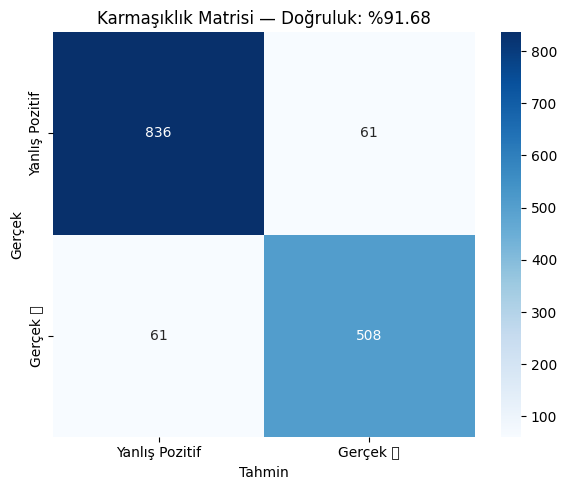

In [8]:
ozellikler = ['yorunge_periyodu_gun', 'transit_suresi_saat', 'transit_derinligi_ppm',
              'gezegen_yaricap_dunya', 'yildiz_sicakligi_K', 'yildiz_yaricap_gunes',
              'denge_sicakligi_K', 'sinyal_gurultu_orani']
uzay_clean = uzay.dropna(subset=ozellikler)
X = uzay_clean[ozellikler]
y = uzay_clean['gercek_gezegen']

X_egitim, X_test, y_egitim, y_test = egitim_test_bol(X, y)
model = rastgele_orman_egit(X_egitim, y_egitim)
dogruluk = model_degerlendir(model, X_test, y_test, sinif_adlari=['Yanlış Pozitif', 'Gerçek 🪐'])

📊 **Karmaşıklık matrisi bu projede nasıl okunur?** Köşegen = doğru tahminler. Köşegen dışı iki hata **aynı değildir**: bir yanlış pozitifi ‘gerçek’ sanmak NASA'ya boşuna teleskop zamanı harcatır; gerçek bir gezegeni kaçırmak ise *yeni bir dünyayı* ıskalamaktır. Doğruluğu mutlaka **baseline** (%62,5 ‘hepsine yanlış-pozitif de’) ile kıyasla.

🔧 **Modeli değiştir, karşılaştır.** Rastgele orman yerine tek karar ağacı ne yapıyor?

🌳 Karar ağacı eğitiliyor (max_derinlik=4)...
✅ Eğitim tamamlandı.
🎯 Doğruluk: %85.20


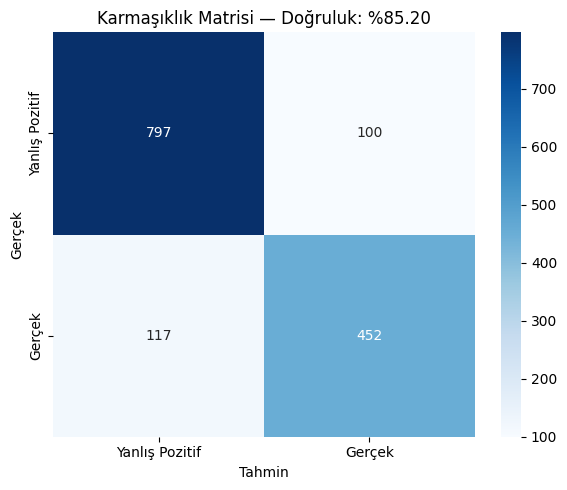

0.8519781718963165

In [9]:
agac = karar_agaci_egit(X_egitim, y_egitim, max_derinlik=4)
model_degerlendir(agac, X_test, y_test, sinif_adlari=['Yanlış Pozitif', 'Gerçek'])

📊 Genelde orman biraz daha doğrudur; ağaç ise *neden* öyle karar verdiğini gösterebilir.

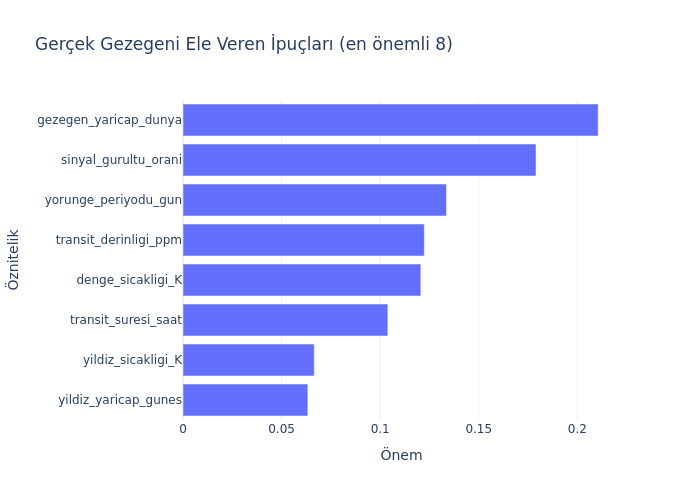

In [10]:
oznitelik_onemi_grafigi(model, oznitelik_adlari=ozellikler, en_iyi_n=8,
                         baslik='Gerçek Gezegeni Ele Veren İpuçları')

📊 **Öznitelik önemi nasıl yorumlanır?** Çubuk ne kadar uzunsa model o ipucuna o kadar güveniyor. Burada genelde **sinyal/gürültü oranı** ve **transit derinliği** öne çıkar — astronomi sezgisiyle uyumlu: net, güçlü, tekrarlayan bir sinyal gerçek gezegeni ele verir. ⚠️ ‘Önemli’ = *modele yararlı*; her zaman fiziksel ‘sebep’ anlamına gelmez.

**Görev:** En önemli 3 öznitelik hangisi? Astronom mantığıyla anlamlı mı? (İpucu: gerçek gezegenler genelde Dünya benzeri küçük; ikili yıldız sistemi büyük "transitler" üretir)

---
### 👥 Grup Tartışması
- Modelin en çok güvendiği ipucu sizce **mantıklı** mı? Bir astronom bu modele güvenir mi?
- Model yanlışlıkla 'gezegen' dediği bir sinyalle koca bir 'keşif' duyurulsa ne olur? Bilimde bir sonucu açıklamadan önce neden tekrar tekrar kontrol ederiz?

## 🌍 Adım 5: Yaşanabilir Bölge Avı

In [11]:
gercek_gezegenler = uzay_clean[uzay_clean['gercek_gezegen']]
yasanabilir = gercek_gezegenler[gercek_gezegenler['yasanabilir_bolge']]
print(f'Gerçek gezegen sayısı: {len(gercek_gezegenler)}')
print(f'Yaşanabilir bölgede: {len(yasanabilir)}')

# Yaşanabilir gezegenlerin yıldız tipi dağılımı
print(f'\nYaşanabilir gezegenlerin yıldız tipi:')
print(yasanabilir.groupby('yildiz_tipi').size())

Gerçek gezegen sayısı: 2745
Yaşanabilir bölgede: 52

Yaşanabilir gezegenlerin yıldız tipi:
yildiz_tipi
G (güneş gibi)      10
K (turuncu)         34
M (kırmızı cüce)     8
dtype: int64


📊 **Yaşanabilir bölge sayıları ne diyor?** Gerçek gezegenlerin yalnızca küçük bir kısmı sıvı su olabilecek mesafede. Bu çıktı, ‘ikinci Dünya’ aramanın neden bu kadar zor olduğunu **sayıyla** gösterir: binlerce adaydan yola çıkıp avuç içi kadar umut verici gezegene iniyoruz.

In [12]:
# Dünya benzeri filtre
dunya_benzeri = yasanabilir[
    (yasanabilir['gezegen_yaricap_dunya'] >= 0.8) &
    (yasanabilir['gezegen_yaricap_dunya'] <= 1.5) &
    (yasanabilir['denge_sicakligi_K'] >= 250) &
    (yasanabilir['denge_sicakligi_K'] <= 350)
]
print(f'🌎 Dünya benzeri sayısı: {len(dunya_benzeri)}')
if len(dunya_benzeri) > 0:
    print('\nİlk 10 Dünya benzeri:')
    print(dunya_benzeri[['aday_id', 'gezegen_yaricap_dunya', 'denge_sicakligi_K',
                          'yorunge_periyodu_gun', 'yildiz_tipi']].head(10).to_string(index=False))

🌎 Dünya benzeri sayısı: 5

İlk 10 Dünya benzeri:
  aday_id  gezegen_yaricap_dunya  denge_sicakligi_K  yorunge_periyodu_gun      yildiz_tipi
K02650.01                   1.14              292.0             34.989785      K (turuncu)
K00571.04                   1.15              319.0             22.407778      K (turuncu)
K03284.01                   0.97              288.0             35.233069      K (turuncu)
K03497.01                   0.80              276.0             20.359719 M (kırmızı cüce)
K02162.02                   1.45              305.0            199.668760   G (güneş gibi)


📊 **‘Dünya benzeri’ liste:** Yarıçap (0,8–1,5 Dünya) ve sıcaklık (250–350 K) filtreleriyle seçilen adaylar. Sunumun **en heyecan verici** anı: ‘işte potansiyel ikinci Dünyalar’. ⚠️ ‘Benzeri’ ≠ ‘yaşam var’ — sadece boyut ve sıcaklık uygun demektir; atmosfer, su, kimya hâlâ bilinmiyor.

## 🔭 Adım 6 (Seçenek): Çok-Gezegenli Sistemler

Bazı yıldızların birden fazla gezegeni var. KOI numarası `K00752.01`, `K00752.02` aynı yıldızın 1. ve 2. gezegeni demek!

In [13]:
# Yıldız ID'sini ayır (K00752.01 → K00752)
uzay_clean['yildiz_id'] = uzay_clean['aday_id'].str.split('.').str[0]
yildiz_gezegen = uzay_clean[uzay_clean['gercek_gezegen']].groupby('yildiz_id').size()
print('Yıldız başına gerçek gezegen sayısı dağılımı:')
print(yildiz_gezegen.value_counts().sort_index())

cok_gezegen = yildiz_gezegen[yildiz_gezegen >= 3]
print(f'\n🔭 3+ gezegenli sistem: {len(cok_gezegen)}')
print(f'En çok gezegenli sistem: {yildiz_gezegen.idxmax()} → {yildiz_gezegen.max()} gezegen')

Yıldız başına gerçek gezegen sayısı dağılımı:
1    1469
2     319
3     123
4      44
5      16
6       1
7       1
Name: count, dtype: int64

🔭 3+ gezegenli sistem: 185
En çok gezegenli sistem: K00351 → 7 gezegen


📊 **Çok-gezegenli sistemler:** Bir yıldızın etrafında birden çok gerçek gezegen olabilir. Tablo, ‘yıldız başına kaç gezegen’ dağılımını verir. Güneş sistemimizde **8** gezegen var; buradaki en kalabalık sistemle karşılaştırmak güzel bir sunum köprüsüdür.

**Görev:** En çok gezegenli sistem kaç gezegen barındırıyor? Güneş sistemimizle karşılaştırın (8 gezegen).

## 😨 Adım 7: Modelin En Güvensiz Olduğu Adaylar

In [14]:
olasiliklar = model.predict_proba(X_test)
guvensizlik = np.abs(olasiliklar[:, 1] - 0.5)
test_df = X_test.copy()
test_df['gercek'] = y_test.values
test_df['olasilik'] = olasiliklar[:, 1]
test_df['guvensizlik'] = guvensizlik

en_guvensiz = test_df.sort_values('guvensizlik').head(10)
print('🤔 Modelin en güvensiz olduğu 10 aday (NASA için "tekrar bak" listesi):')
print(en_guvensiz[['gezegen_yaricap_dunya', 'transit_derinligi_ppm',
                    'sinyal_gurultu_orani', 'olasilik', 'gercek']].to_string())

🤔 Modelin en güvensiz olduğu 10 aday (NASA için "tekrar bak" listesi):
      gezegen_yaricap_dunya  transit_derinligi_ppm  sinyal_gurultu_orani  olasilik  gercek
5193                   0.54                   34.7                  10.8      0.50   False
1870                   1.93                  371.0                  14.7      0.50    True
3800                   1.32                  242.6                  16.3      0.51   False
705                    3.07                  194.3                  37.6      0.49   False
1128                   5.33                 1534.4                 138.4      0.51   False
6412                  11.40                  633.0                  27.9      0.49   False
69                     3.12                  837.5                  64.5      0.49    True
3095                   1.40                  170.2                  48.4      0.49   False
2406                  10.81                 5060.0                 136.4      0.49    True
4302               

📊 **Modelin en güvensiz olduğu adaylar:** Olasılığı **%50'ye en yakın** olanlar — model resmen ‘kararsız’. Bunlar NASA için ‘tekrar bak’ listesidir. Bir modelin yalnızca tahminini değil, **ne kadar emin olduğunu** da bilmek çok değerlidir: ‘bilmediğini bilen’ bir yapay zekâ daha güvenlidir.

---
### 👥 Grup Tartışması — Sunuma Hazırlık
- Bugün bulduğunuz **en şaşırtıcı** şey neydi? Grupça tek bir 'baş bulgu' seçin.
- Sizi dinleyen biri 'ee, ne olmuş?' derse nasıl cevap verirsiniz? Bulgunuz neden önemli?

## Adım 8: Sunum için notlarınız

- Toplam aday sayısı: ___
- Gerçek gezegen oranı: %___
- 🌟 En çok aday hangi yıldız tipinde: ___
- 🔥 Sıcak Jüpiter sayısı: ___ (en sıcak ___ K)
- 🌍 Yaşanabilir bölgedeki gerçek gezegen: ___
- 🌎 Dünya benzeri sayısı: ___
- 🔭 En çok gezegenli sistem: ___ gezegen
- Modelin doğruluğu: %___
- En önemli 3 öznitelik:

  1. ___________
  2. ___________
  3. ___________
- **Şaşırtıcı bulgu:** _________________________
- **Kariyer:** NASA'da ML mühendisi olmak ister misiniz? TÜBİTAK Uzay Araştırmaları Enstitüsü Türkiye'de var!

🚀 **Sunum ipucu:** Slaytınıza NASA görseli ekleyin (kamuya açık, ücretsiz!).

📝 Bilimsel yöntem şablonunu doldurun!

## 🎤 Sunum & Yorumlama Rehberi

> Bu bölüm, projeyi **son gün sunarken** ne anlatacağını ve sonuçları **nasıl yorumlayacağını** özetler. Ezberleme — kendi cümlelerinle anlat.

**🪐 Ana mesaj (bir cümle):** *“Binlerce Kepler adayından gerçek gezegenleri yanlış alarmlardan ayırmayı ve içlerinden Dünya benzerlerini bulmayı öğrendik.”*

**Grafik sırası:** ① yıldız tipi (sayı + oran) → ② yörünge-yarıçap dağılımı (Sıcak Jüpiter köşesi) → ③ karmaşıklık matrisi + doğruluk → ④ öznitelik önemi → ⑤ Dünya benzeri liste (final).

**Yorumlama anahtarları:** doğruluğu **baseline** ile kıyasla; iki **hata türünü** ayır; ‘en güvensiz adaylar’ı *tekrar-bak listesi* diye sun.

**Sık hatalar:** ❌ ‘%95 doğru = kusursuz’ (hata türüne bak) · ❌ ‘önemli öznitelik = sebep’ · ❌ aday **sayısı** ile gerçek **oranını** karıştırmak.

---
## 🚀 Hızlı Bitirenler İçin BONUS

1. **Süper-Dünyalar:** Yarıçap 1.5-2.5 Dünya arası — kaç tane?
2. **Mini-Neptünler:** Yarıçap 2-4 Dünya — "ara cins" gezegenler, Güneş sistemimizde yok!
3. **TRAPPIST-1 sistemi:** 7 Dünya benzeri gezegen tek yıldız etrafında. Bu veride benzer sistem var mı?
4. **Habitabilite haritası:** Yıldız sıcaklığı vs gezegen-yıldız uzaklığı, yaşanabilir bölgeyi gösteren grafik
5. **Kümeleme:** `KMeans` ile 4 kümeye ayır — kayalı, gaz, sıcak, soğuk gibi grupları görebiliyor musunuz?

## 🆘 Yardım — Sık Karşılaşılan Hatalar

**❌ `KeyError: 'gercek_gezegen'`** → Boolean sütun. `y = uzay['gercek_gezegen']`

**❌ Doğruluk %100** → Veri sızıntısı. `yasanabilir_bolge` veya `durum` X'te olmamalı

**❌ Dünya benzeri = 0** → Bu doğru olabilir! Gerçek hayatta da Dünya benzeri çok azdır. Filtreleri biraz gevşetin

**❌ NaN bol** → `denge_sicakligi_K` bazılarında eksik. `dropna(subset=ozellikler)` kullanın

**❌ Yıldız tipi sütunu çıkmadı** → `apply` fonksiyonunu çağırdınız mı? `uzay['yildiz_tipi'] = uzay['yildiz_sicakligi_K'].apply(yildiz_tipi)`

---
# 🧑‍🏫 Öğretmen Rehberi & Cevap Anahtarı
*Bu bölüm öğretmen içindir: beklenen sonuçlar, sık takılma noktaları ve tartışma soruları. Öğrenciler projeyi yaptıktan sonra bakabilir.*

# 🎓 PROJE 1 EĞİTMEN — Uzay (Ötegezegen Tespiti)
## Mini Proje Saha Rehberi

**Bu notebook eğitmenler içindir.**

## ⚠️ Veri Hakkında

Bu **GERÇEK NASA verisidir** — NASA Exoplanet Archive (exoplanetarchive.ipac.caltech.edu) TAP API'sinden çekildi. KOI numaraları gerçek (K00752, K00754, vb.). Sınıfta açıklayın:

> "Bu veri **gerçek NASA Kepler verisidir**. K00752 = Kepler-227 sistemi. Bu ötegezegenler 2009-2018 arası gerçekten gözlemlendi."

## 👥 Bu Projeyi Kim Seçer?
- Astronomi/uzay merakı olanlar (çoğunluk!)
- Bilim kurgu sevenler
- "Yeni bir Dünya keşfedebilir miyiz?" sorusu cazip gelenler
- Saf sayısal sınıflandırma sevenler (kategorik öznitelik yok, encoding gerekmiyor)

## 🎯 Beklenen Çıktı (2 saat sonunda)
- Gerçek/yanlış pozitif sınıflandırma modeli
- En önemli ipuçları belirlenmiş (genelde SNR ve transit derinliği)
- Yaşanabilir bölge sayımı yapılmış
- Dünya benzeri gezegen filtrelemesi (genelde 0-3 örnek bulunur — gerçeğe yakın)

## 📊 Beklenen Sayısal Sonuçlar
- **Toplam aday:** ~7300 (gerçek NASA Kepler kataloğu, sadece CONFIRMED + FALSE POSITIVE etiketli olanlar)
- **Gerçek gezegen oranı:** ~%37-38 (gerçekte yanlış pozitifler daha çok)
- **Yaşanabilir bölgedeki gerçek gezegen sayısı:** ~50-55 (gerçek Kepler bulgularıyla uyumlu!)
- **Rastgele Orman doğruluk:** ~%90-92 (gerçek veride güçlü)
- **En önemli öznitelikler (genelde):**
  1. `sinyal_gurultu_orani` (en güçlü)
  2. `transit_derinligi_ppm`
  3. `gezegen_yaricap_dunya`
- **Dünya benzeri sayısı (filtrelenmiş):** ~5-15 aday

## ⚠️ Tipik Takılma Noktaları

**1. "yasanabilir_bolge sütunu sınıflandırmaya da girmiş, doğruluk %100"**
→ `yasanabilir_bolge` öznitelik DEĞİL, ek hedef. `X = uzay[ozellikler]` listesinde olmamalı. Veri sızıntısı uyarısı verin

**2. "Dünya benzeri 0 buldum"**
→ Bu DOĞRU olabilir! Gerçek hayatta Dünya benzeri çok az (Kepler ~50 tane). Bu sentetik veride genelde 5-15 olur. Filtreleri biraz gevşetmelerini söyleyin

**3. "Modelimin doğruluğu %62 — bu kötü mü?"**
→ Bu **baseline** (her şeyi gerçek desek) % 62 zaten. Model bunu geçmeli. Beklenen ~%90-92. Eğer modelin %62 ise bir şey yanlış — `n_estimators=100` olduğundan emin olun

**4. Boolean sütun karışıklığı**
→ `gercek_gezegen` True/False. Bazı öğrenciler `== 1` veya `== 'True'` deneyebilir. Hatırlatın: Pandas boolean'da doğrudan filtreleme yapar (`uzay[uzay['gercek_gezegen']]`)

**5. "SNR neden bu kadar baskın?"**
→ Sentetik veride SNR ana ipucu olarak inşa edildi (gerçek hayatta da öyle). Açıklayın: "Düşük SNR = belirsiz sinyal = muhtemelen gürültü/yanlış pozitif"

## 🎯 Derinleştirme Soruları

1. "Sıcak Jüpiterler kaç tane?" → Yörünge < 10 gün + yarıçap > 8 Dünya
2. "M cüceler etrafındaki gezegenler farklı mı?" → Yıldız sıcaklığı < 4000K filtresi
3. "Eşit-yarıçaplı gezegenleri (1-2 Dünya) ayırırsa, model hangi sıcaklıklarda daha iyi?"
4. "Gerçek hayatta NASA bu modeli kullanırsa, %2 yanlış pozitif verirse 10000 adayda 200 yanlış. Astronomlar 200 adayı manuel inceler. Ne kadar zaman / para kaybeder?"
5. "Modelin tahmin olasılığı 0.4-0.6 olan adayları izole edin — bunlar 'tekrar bakılacak' kümesi. NASA'nın gerçek iş akışı bu!"

## 💭 Etik / Sosyal Tartışma

Uzay araştırmasının etik sorusu şaşırtıcı olabilir:

> "Yaşanabilir bir gezegen bulsak ve oraya 'merhaba' sinyali yollasak, ne riskler var?"

Yönlendirme noktaları:
- **METI tartışması:** Sinyal gönderme = pozisyonumuzu açıklama. Stephen Hawking riskli buldu
- **Bilim yarışı:** Hangi ülke önce keşfederse 'sahip olur' mu? (Cevap: hayır, ama prestij var)
- **Bilimsel yayın:** Algoritma kararı verir, ama insan doğrular. Bu sıralama önemli (otomatik karar tehlikeli)
- **NASA bütçesi:** Vergi paramız uzaya gitsin mi? Sosyal sorunlara gitsin mi? Bu ahlaki bir karar
- **"Yapay Zeka NASA'yı işten çıkardı":** Algoritmalar her geçen yıl daha çok karar veriyor. Astronomların işi azalıyor mu?

## 🎤 Sunum Koçluğu

Uzay sunumları **görsel olarak çok güçlü** olabilir:
- 1 NASA görseli (telif yok, kamuya açık) — Kepler uydusu, ötegezegen sanatçı çizimi
- Karmaşıklık matrisi (gerçek vs yanlış pozitif)
- En önemli 3 öznitelik
- **"Bizim Dünya benzeri listemiz"** tablosu — sınıfa heyecan verir
- Etik kapanış: "Kimse algoritmaya tek başına güvenip 'yeni bir Dünya bulduk' demez. Niye?"

**Bonus kariyer kıvılcımı:** "NASA'da makine öğrenmesi çalışan astronomlar var. Türkiye'de TÜBİTAK Uzay Araştırmaları, TUBİTAK Bilim Kampı — siz de oraya gidebilirsiniz."